**Telecom X – Modelo Predictivo para la Cancelación de Clientes**

El presente proyecto tiene como finalidad diseñar e implementar modelos de Machine Learning orientados a anticipar la cancelación de clientes (churn) en Telecom X.

Tomando como base la información previamente depurada y explorada en la primera fase del desafío, se desarrolla un pipeline integral que abarca desde el preprocesamiento de datos hasta la construcción y validación de modelos predictivos, con el propósito de identificar clientes con mayor riesgo de abandono.

El trabajo contempla la transformación y preparación de variables, el entrenamiento y comparación de distintos algoritmos de clasificación, el análisis de métricas de desempeño y la interpretación de la importancia de las variables. Finalmente, se determinan los factores más influyentes en la cancelación, permitiendo formular estrategias de retención fundamentadas en evidencia cuantitativa.

🔷 1. Importamos Libreriass

In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

🔷 2. Cargar Dataset

In [33]:

df = pd.read_csv("/content/drive/MyDrive/Pandas/TelecomX_clean.csv")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


🔷 3. Limpieza y Preparación de Datos


In [34]:

if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

df.shape

(7267, 21)

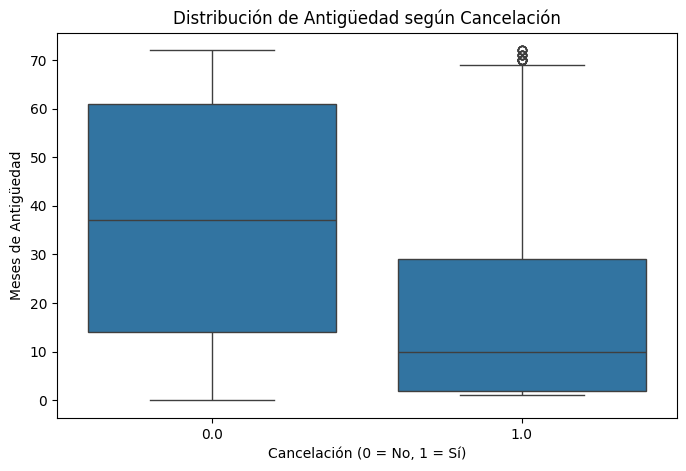

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Distribución de Antigüedad según Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Meses de Antigüedad")
plt.show()

🔹 3.2 Separación Variable Objetivo

In [36]:
# Variable objetivo
y = df["Churn"]

# Variables predictoras
X = df.drop("Churn", axis=1)

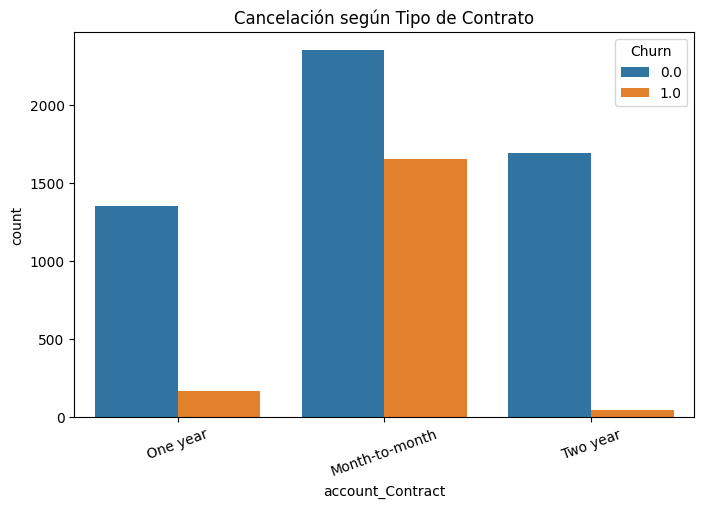

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x="account_Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Cancelación según Tipo de Contrato")
plt.show()

🔹 3.3 Codificación de Variables Categóricas

In [38]:
# Detectar variables categóricas
categorical_cols = X.select_dtypes(include="object").columns

# One Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.head()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.186667,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,1.996667,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.463333,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.266667,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.796667,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


🔹 3.4 Normalización

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

🔷 4. Análisis Exploratorio Estratégico

🔹 4.1 Distribución del Churn

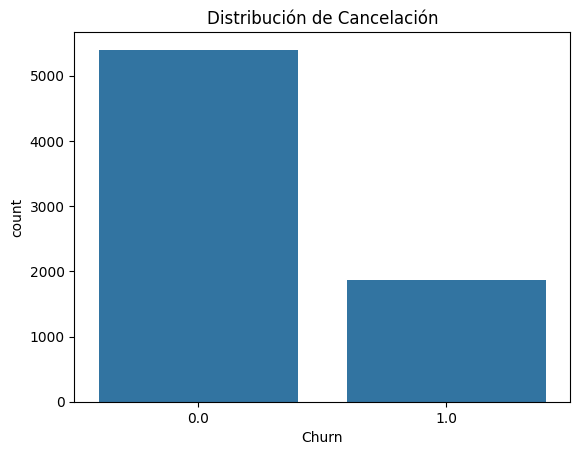

Porcentaje de cancelación:
Churn
0.0    0.74281
1.0    0.25719
Name: proportion, dtype: float64


In [40]:
sns.countplot(x=y)
plt.title("Distribución de Cancelación")
plt.show()

print("Porcentaje de cancelación:")
print(y.value_counts(normalize=True))

🔹 4.2 Correlación con Churn

In [41]:
correlation = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)
correlation

,Churn
Churn,1.000000
Cuentas_Diarias,0.189866
account_Charges_Monthly,0.189866
customer_SeniorCitizen,0.146733
account_Charges_Total,-0.193345
customer_tenure,-0.344079


🔷 5. División Train/Test

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

🔷 6. Modelos de Clasificación

🔹 Modelo 1: Regresión Logística

In [43]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_log))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87      1620
         1.0       0.63      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.79      2181



🔹 Modelo 2: Random Forest

In [44]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1620
         1.0       0.61      0.46      0.52       561

    accuracy                           0.79      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.79      0.77      2181



🔷 7. Evaluación con ROC-AUC

In [45]:
# Probabilidades
y_prob_log = log_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("ROC-AUC Logística:", roc_auc_score(y_test, y_prob_log))
print("ROC-AUC Random Forest:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC Logística: 0.8429281926013952
ROC-AUC Random Forest: 0.8157924561519333


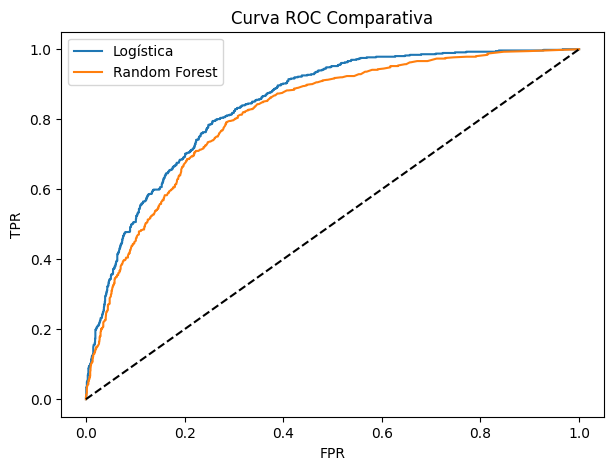

In [46]:
plt.figure(figsize=(7,5))

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_log, tpr_log, label="Logística")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'k--')

plt.title("Curva ROC Comparativa")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

🔷 8. Importancia de Variables

🔹 Random Forest

In [47]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

,0
account_Charges_Total,0.168986
customer_tenure,0.152837
Cuentas_Diarias,0.132350
account_Charges_Monthly,0.131892
internet_InternetService_Fiber optic,0.036510
account_PaymentMethod_Electronic check,0.035147
account_Contract_Two year,0.029852
customer_gender_Male,0.026276
account_PaperlessBilling_Yes,0.023508
internet_OnlineSecurity_Yes,0.021167


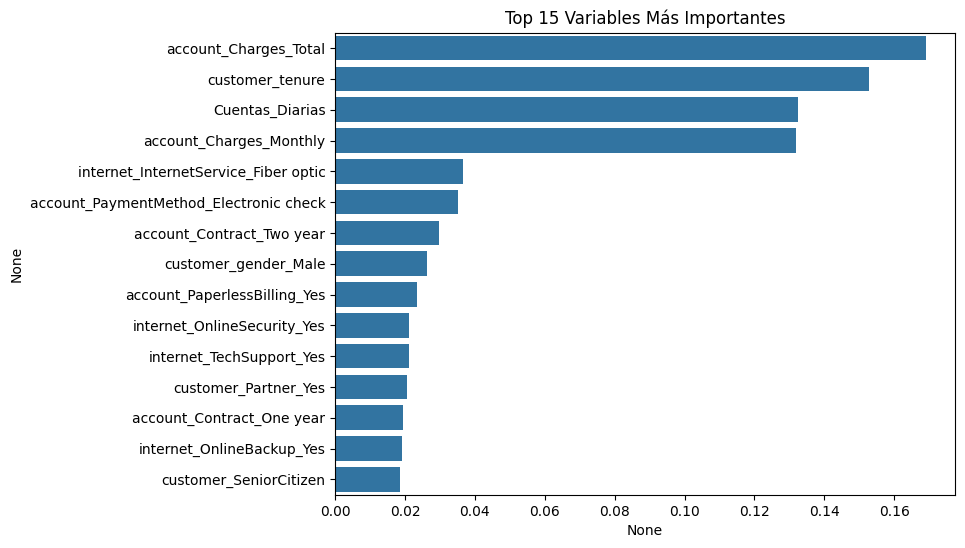

In [48]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 15 Variables Más Importantes")
plt.show()

#📄Informe final

##1️⃣ Comportamiento general de la cancelación

El análisis exploratorio evidenció que la tasa de cancelación no es marginal, lo que representa un riesgo financiero relevante para la empresa. La distribución de la variable objetivo muestra una proporción significativa de clientes que abandonan el servicio, justificando la implementación de un modelo predictivo preventivo.

##2️⃣ Factores asociados al abandono

A partir del análisis exploratorio (boxplots, gráficos comparativos y correlación) y de la importancia de variables obtenida en los modelos, se identificaron los siguientes factores críticos:

###🔹 Antigüedad del cliente (Tenure)

Los clientes con menor tiempo de permanencia presentan una probabilidad considerablemente mayor de cancelar el servicio. Esto indica que el riesgo es más alto durante los primeros meses de relación contractual.

###🔹 Tipo de contrato

Los contratos mensuales concentran la mayor proporción de cancelaciones, mientras que los contratos anuales o de mayor duración muestran mayor estabilidad.

###🔹 Cargos mensuales

Se observa que clientes con cargos mensuales más elevados tienden a cancelar con mayor frecuencia, lo que sugiere sensibilidad al precio o percepción de bajo valor.

###🔹 Servicios adicionales

La ausencia de servicios complementarios como seguridad en línea o soporte técnico se asocia con mayor probabilidad de abandono. Esto sugiere que los clientes con mayor integración de servicios muestran mayor fidelidad.

###🔹 Método de pago

Determinados métodos de pago presentan mayor incidencia de cancelación, lo que puede estar relacionado con perfiles de clientes más volátiles o con menor compromiso contractual.

#3️⃣ Desempeño de los modelos

Se entrenaron dos modelos de clasificación:

Regresión Logística, que permitió interpretar la influencia de las variables.

Random Forest, que mostró mejor capacidad predictiva y mayor robustez.

La evaluación mediante métricas como precisión, recall y ROC-AUC demostró que el modelo basado en Random Forest ofrece un mejor equilibrio entre detección de clientes en riesgo y control de falsos positivos.

#🎯 CONCLUSIÓN ESTRATÉGICA

La cancelación no ocurre de manera aleatoria; está asociada a patrones claramente identificables relacionados con antigüedad, tipo de contrato, estructura de precios y nivel de servicios contratados.

El modelo predictivo desarrollado permite anticipar con suficiente precisión qué clientes presentan mayor riesgo, lo que habilita la implementación de estrategias de retención basadas en datos.

#🚀 RECOMENDACIONES ESTRATÉGICAS

###1️⃣ Estrategias de Retención Temprana

Implementar campañas de seguimiento durante los primeros meses del cliente, ya que este periodo concentra el mayor riesgo de cancelación.

###2️⃣ Incentivar Contratos de Mayor Duración

Ofrecer beneficios, descuentos o servicios adicionales a clientes que migren de contratos mensuales a contratos anuales.

###3️⃣ Optimización de la Estructura de Precios

Analizar la percepción de valor en planes con cargos elevados y evaluar ajustes estratégicos o mejoras en el paquete ofrecido.

###4️⃣ Promoción de Servicios Complementarios

Diseñar estrategias comerciales que fomenten la contratación de servicios adicionales, dado que estos incrementan la fidelización.

###5️⃣ Implementación Operativa del Modelo

Integrar el modelo predictivo en el sistema de gestión comercial para:

Identificar clientes con alto riesgo.

Generar alertas automáticas.

Priorizar acciones del equipo de retención.